# 04 — Analyse comparative des modèles CNN

Ce notebook analyse les résultats d'évaluation obtenus sur le jeu de validation pour les différents modèles CNN entraînés.

L'objectif est de comparer les architectures selon plusieurs métriques :
- accuracy ;
- precision macro ;
- recall macro ;
- F1-score macro ;
- F1-score pondéré ;
- nombre d'erreurs.

Le jeu de validation est utilisé pour comparer les modèles sans toucher au jeu de test, qui sera réservé à l'évaluation finale du modèle retenu.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
COMPARISON_PATH = PROJECT_ROOT / "reports" / "evaluation" / "model_comparison_val_final_100epochs.csv"

df = pd.read_csv(COMPARISON_PATH)

In [3]:
# Nettoyage des noms de runs
def simplify_run_name(row):
    architecture = row["architecture"]
    run_name = row["run_name"]

    if "finetune-True" in run_name:
        strategy = "fine-tuning"
    elif "freeze-True" in run_name:
        strategy = "frozen backbone"
    else:
        strategy = "from scratch"

    return f"{architecture} | {strategy}"


df["model_label"] = df.apply(simplify_run_name, axis=1)

df_sorted = df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

df_sorted[
    [
        "model_label",
        "architecture",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "best_val_loss",
        "num_errors",
    ]
]

,model_label,architecture,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_val_loss,num_errors
0,resnet50 | fine-tuning,resnet50,0.861538,0.857143,0.882631,0.865622,0.859948,0.550740,9
1,mobilenet_v3_large | frozen backbone,mobilenet_v3_large,0.861538,0.887884,0.844933,0.847690,0.855842,0.506428,9
2,resnet50 | frozen backbone,resnet50,0.753846,0.720738,0.757631,0.721872,0.755468,1.162637,16
3,vgg16 | frozen backbone,vgg16,0.523077,0.647747,0.598596,0.557960,0.566058,1.326363,31
4,efficientnet_b0 | frozen backbone,efficientnet_b0,0.476923,0.527751,0.514347,0.464577,0.502859,1.338394,34
5,custom_cnn | from scratch,custom_cnn,0.430769,0.502588,0.397283,0.399341,0.418949,1.691309,37


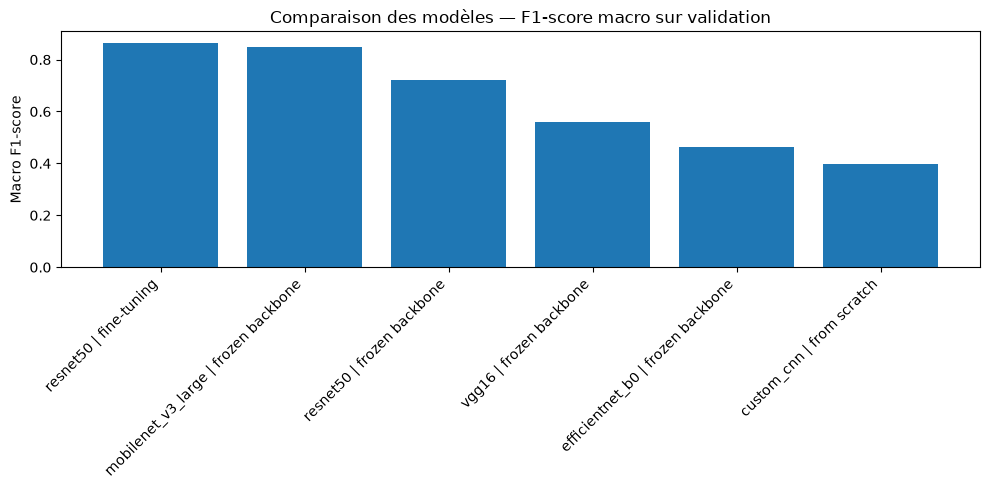

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(df_sorted["model_label"], df_sorted["macro_f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1-score")
plt.title("Comparaison des modèles — F1-score macro sur validation")
plt.tight_layout()
plt.show()

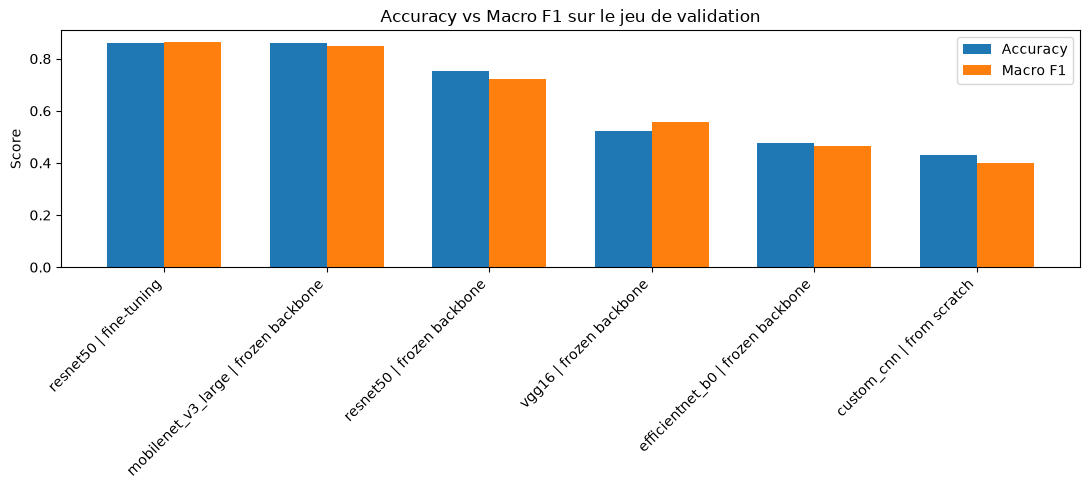

In [5]:
x = np.arange(len(df_sorted))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, df_sorted["accuracy"], width, label="Accuracy")
plt.bar(x + width / 2, df_sorted["macro_f1"], width, label="Macro F1")

plt.xticks(x, df_sorted["model_label"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Accuracy vs Macro F1 sur le jeu de validation")
plt.legend()
plt.tight_layout()
plt.show()

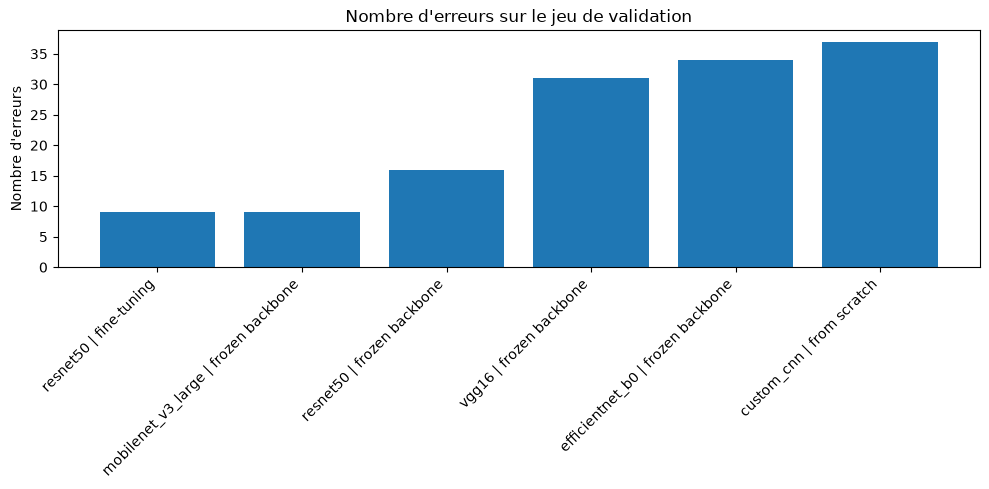

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(df_sorted["model_label"], df_sorted["num_errors"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre d'erreurs")
plt.title("Nombre d'erreurs sur le jeu de validation")
plt.tight_layout()
plt.show()

## Comparaison des recalls par classe

L'accuracy globale ne suffit pas pour comparer les modèles, car le dataset est déséquilibré.  
Le recall par classe permet de mesurer la proportion d'images réellement appartenant à une classe que le modèle parvient à identifier correctement.

Cette métrique est particulièrement importante pour les classes minoritaires comme `Ingrown_nails` et `Stab_wound`, qui risquent d'être moins bien reconnues si le modèle privilégie les classes majoritaires.

In [7]:
reports = []

for _, row in df_sorted.iterrows():
    run_name = row["run_name"]
    model_label = row["model_label"]

    report_path = (
        PROJECT_ROOT
        / "reports"
        / "evaluation"
        / run_name
        / "val"
        / "classification_report.csv"
    )

    if not report_path.exists():
        print(f"Rapport absent pour : {model_label}")
        continue

    report_df = pd.read_csv(report_path, index_col=0)

    # On garde uniquement les vraies classes, pas les moyennes globales
    class_rows = report_df.loc[
        [idx for idx in report_df.index if idx not in ["accuracy", "macro avg", "weighted avg"]]
    ].copy()

    class_rows["model_label"] = model_label
    class_rows["run_name"] = run_name

    reports.append(class_rows.reset_index().rename(columns={"index": "class"}))

recall_comparison_df = pd.concat(reports, ignore_index=True)

recall_comparison_df.head()

,class,precision,recall,f1-score,support,model_label,run_name
0,Abrasions,0.900000,0.692308,0.782609,13.0,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
1,Bruises,0.944444,0.944444,0.944444,18.0,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
2,Burns,0.800000,0.888889,0.842105,9.0,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
3,Cut,0.777778,0.875000,0.823529,8.0,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
4,Ingrown_nails,0.800000,1.000000,0.888889,4.0,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...


In [8]:
recall_pivot = recall_comparison_df.pivot_table(
    index="class",
    columns="model_label",
    values="recall"
)

recall_pivot

recall_pivot_rounded = recall_pivot.round(3)
recall_pivot_rounded

model_label,custom_cnn | from scratch,efficientnet_b0 | frozen backbone,mobilenet_v3_large | frozen backbone,resnet50 | fine-tuning,resnet50 | frozen backbone,vgg16 | frozen backbone
class,,,,,,
Abrasions,0.462,0.462,0.692,0.692,0.692,0.385
Bruises,0.556,0.389,0.944,0.944,0.889,0.444
Burns,0.556,0.222,1.000,0.889,0.556,0.444
Cut,0.125,0.500,1.000,0.875,0.750,0.500
Ingrown_nails,0.500,0.750,1.000,1.000,1.000,1.000
Laceration,0.333,0.778,0.778,0.778,0.667,0.667
Stab_wound,0.250,0.500,0.500,1.000,0.750,0.750


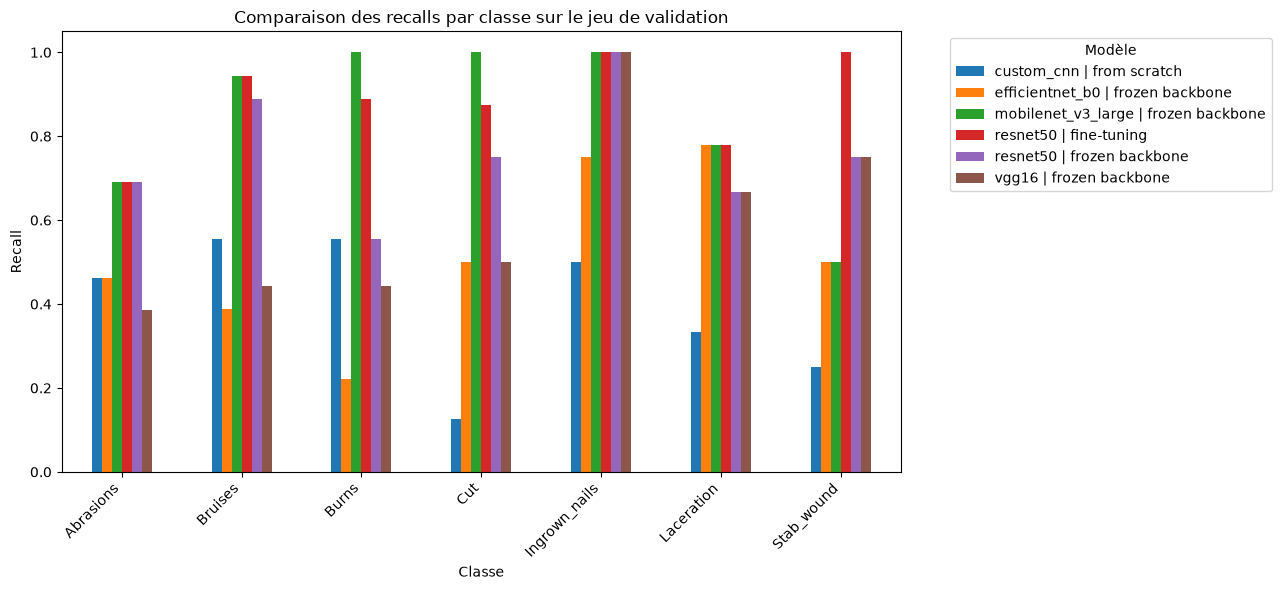

In [9]:
recall_pivot_rounded.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Comparaison des recalls par classe sur le jeu de validation")
plt.xlabel("Classe")
plt.ylabel("Recall")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

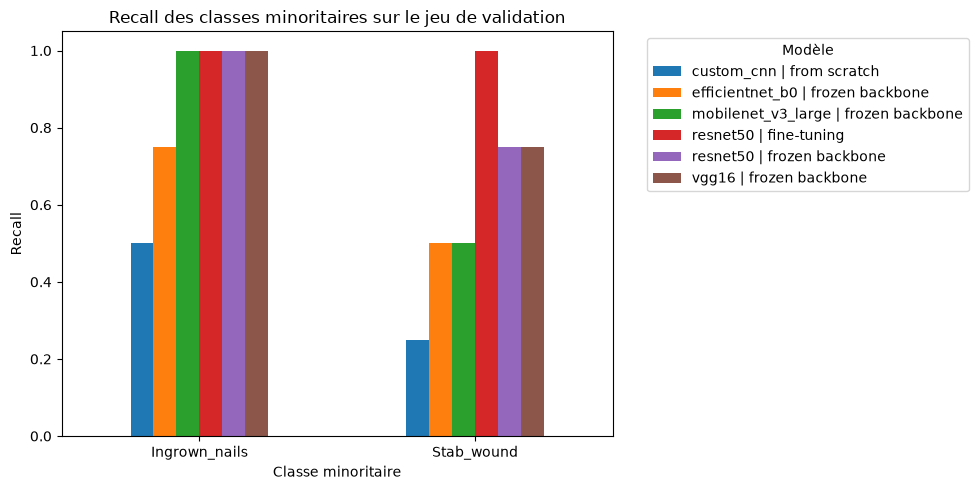

In [10]:
minority_classes = ["Ingrown_nails", "Stab_wound"]

minority_recall_df = recall_pivot_rounded.loc[
    [cls for cls in minority_classes if cls in recall_pivot_rounded.index]
]

minority_recall_df

minority_recall_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Recall des classes minoritaires sur le jeu de validation")
plt.xlabel("Classe minoritaire")
plt.ylabel("Recall")
plt.xticks(rotation=0)
plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
best_recall_by_class = recall_pivot.idxmax(axis=1).to_frame(name="best_model")
best_recall_by_class["best_recall"] = recall_pivot.max(axis=1).round(3)

best_recall_by_class

,best_model,best_recall
class,,
Abrasions,mobilenet_v3_large | frozen backbone,0.692
Bruises,mobilenet_v3_large | frozen backbone,0.944
Burns,mobilenet_v3_large | frozen backbone,1.000
Cut,mobilenet_v3_large | frozen backbone,1.000
Ingrown_nails,mobilenet_v3_large | frozen backbone,1.000
Laceration,efficientnet_b0 | frozen backbone,0.778
Stab_wound,resnet50 | fine-tuning,1.000


## Matrices de confusion

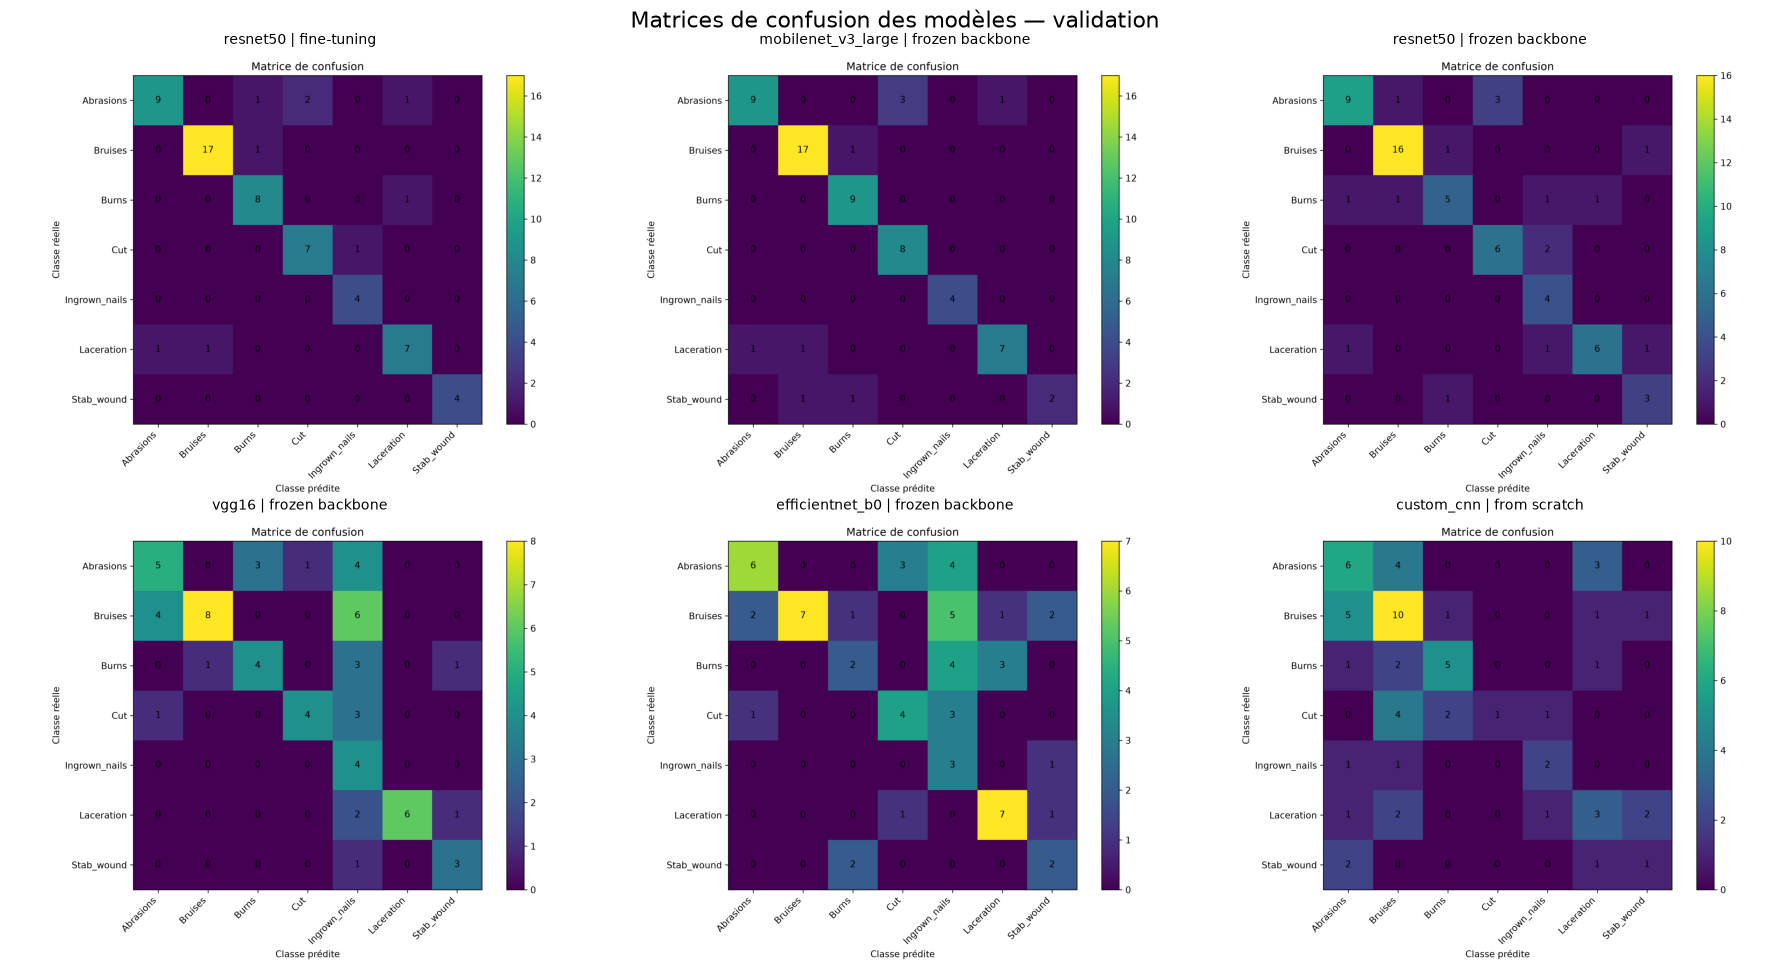

In [31]:
from PIL import Image
import math

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, (_, row) in enumerate(df_sorted.iterrows()):
    if ax_idx >= n_rows * n_cols:
        break

    run_name = row["run_name"]
    model_label = row["model_label"]

    cm_path = (
        PROJECT_ROOT
        / "reports"
        / "evaluation"
        / run_name
        / "val"
        / "confusion_matrix.png"
    )

    ax = axes[ax_idx]

    if not cm_path.exists():
        ax.axis("off")
        ax.set_title(f"Matrice absente\n{model_label}")
        continue

    img = Image.open(cm_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(model_label, fontsize=10)

# Masquer les cases vides si moins de 6 modèles
for ax in axes[len(df_sorted):]:
    ax.axis("off")

plt.suptitle("Matrices de confusion des modèles — validation", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
best_model = df_sorted.iloc[0]

best_model

run_name              resnet50_pretrained-True_freeze-False_finetune...
architecture                                                   resnet50
split                                                               val
accuracy                                                       0.861538
macro_precision                                                0.857143
macro_recall                                                   0.882631
macro_f1                                                       0.865622
weighted_precision                                             0.866496
weighted_recall                                                0.861538
weighted_f1                                                    0.859948
best_val_acc                                                   0.861538
best_val_loss                                                   0.55074
num_samples                                                          65
num_errors                                                      

## Courbes d'entraînement

Les courbes d'entraînement permettent d'analyser la dynamique d'apprentissage des modèles.

Elles sont utiles pour identifier :
- une convergence stable ;
- un sous-apprentissage ;
- un surapprentissage ;
- l'effet de l'early stopping ;
- l'écart entre les performances train et validation.

Dans ce projet, elles sont particulièrement importantes car le dataset est petit et déséquilibré. Un modèle peut rapidement obtenir une bonne performance sur le train tout en généralisant mal sur la validation.

In [14]:
histories = []

for _, row in df_sorted.iterrows():
    run_name = row["run_name"]
    model_label = row["model_label"]

    history_path = (
        PROJECT_ROOT
        / "reports"
        / "evaluation"
        / run_name
        / "val"
        / "training_history.csv"
    )

    if not history_path.exists():
        print(f"Historique absent pour : {model_label}")
        continue

    history_df = pd.read_csv(history_path)
    history_df["model_label"] = model_label
    history_df["run_name"] = run_name

    histories.append(history_df)

history_all_df = pd.concat(histories, ignore_index=True)

history_all_df.head()

,epoch,train_loss,train_acc,val_loss,val_acc,lr,precision_macro,recall_macro,f1_macro,model_label,run_name
0,1,1.943825,0.169435,1.958675,0.169231,0.00001,0.129365,0.170024,0.131286,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
1,2,1.930621,0.189369,1.943717,0.215385,0.00001,0.224150,0.239469,0.205932,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
2,3,1.921254,0.202658,1.936028,0.215385,0.00001,0.230277,0.239469,0.208210,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
3,4,1.911017,0.182724,1.925298,0.215385,0.00001,0.206236,0.239469,0.200951,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
4,5,1.877324,0.242525,1.911873,0.246154,0.00001,0.204902,0.291056,0.217599,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...


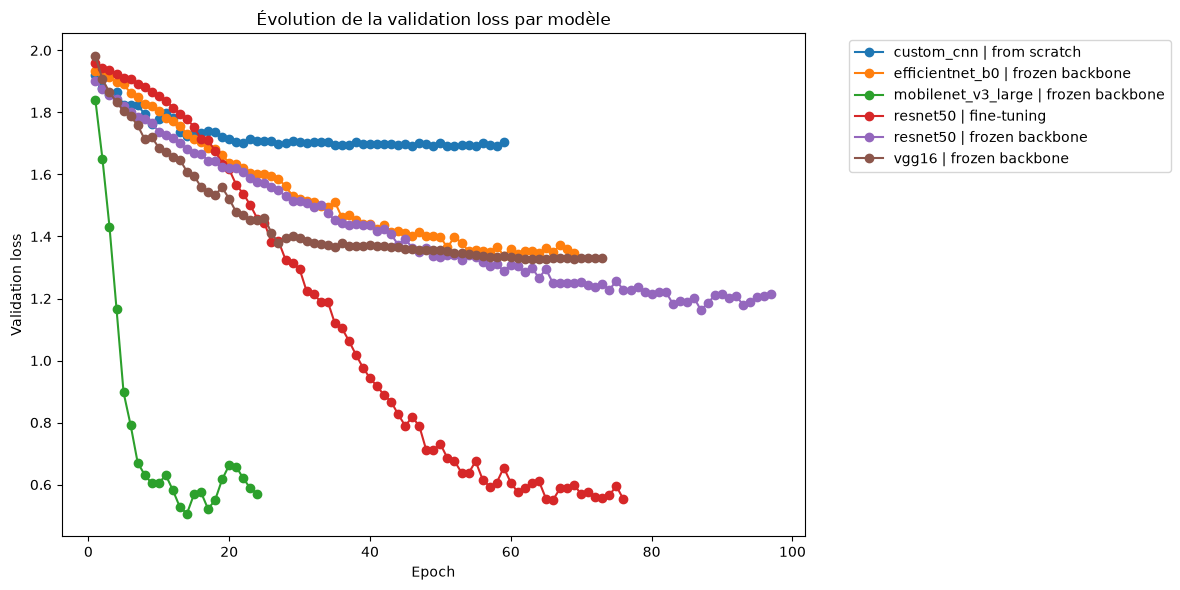

In [15]:
plt.figure(figsize=(12, 6))

for model_label, group in history_all_df.groupby("model_label"):
    plt.plot(
        group["epoch"],
        group["val_loss"],
        marker="o",
        label=model_label
    )

plt.title("Évolution de la validation loss par modèle")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

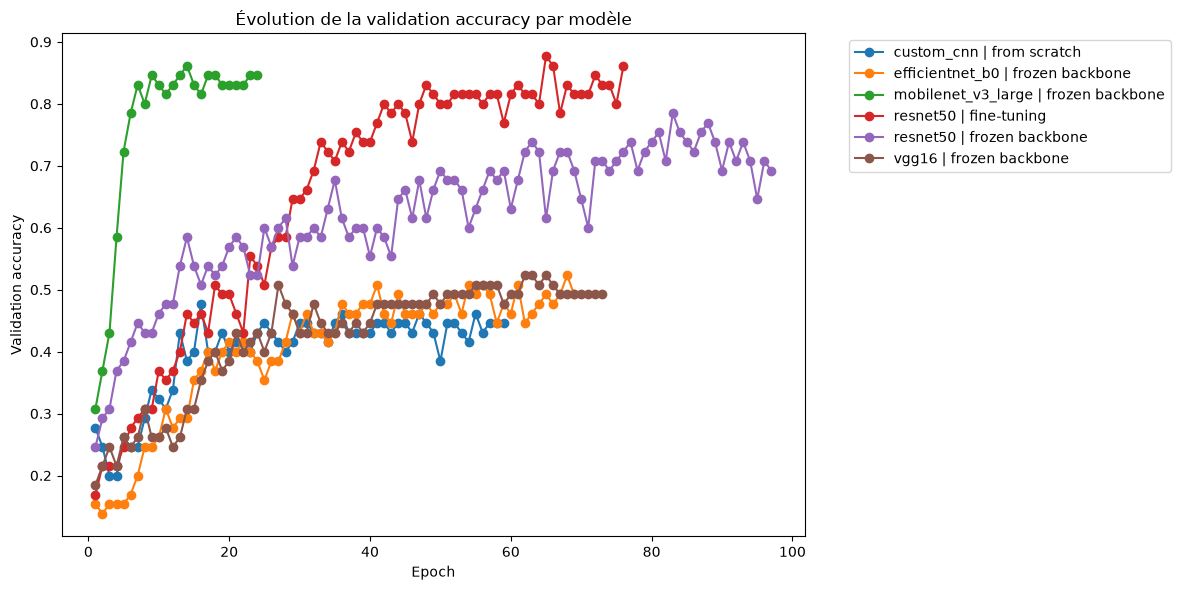

In [16]:
plt.figure(figsize=(12, 6))

for model_label, group in history_all_df.groupby("model_label"):
    plt.plot(
        group["epoch"],
        group["val_acc"],
        marker="o",
        label=model_label
    )

plt.title("Évolution de la validation accuracy par modèle")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
best_history = history_all_df[
    history_all_df["run_name"] == best_model["run_name"]
].copy()

best_history

,epoch,train_loss,train_acc,val_loss,val_acc,lr,precision_macro,recall_macro,f1_macro,model_label,run_name
0,1,1.943825,0.169435,1.958675,0.169231,1.000000e-05,0.129365,0.170024,0.131286,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
1,2,1.930621,0.189369,1.943717,0.215385,1.000000e-05,0.224150,0.239469,0.205932,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
2,3,1.921254,0.202658,1.936028,0.215385,1.000000e-05,0.230277,0.239469,0.208210,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
3,4,1.911017,0.182724,1.925298,0.215385,1.000000e-05,0.206236,0.239469,0.200951,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
4,5,1.877324,0.242525,1.911873,0.246154,1.000000e-05,0.204902,0.291056,0.217599,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
...,...,...,...,...,...,...,...,...,...,...,...
71,72,0.227941,0.963455,0.558611,0.846154,6.250000e-07,0.840873,0.863706,0.842783,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
72,73,0.197090,0.973422,0.557693,0.830769,6.250000e-07,0.835359,0.860653,0.838876,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
73,74,0.238066,0.963455,0.567117,0.830769,6.250000e-07,0.822042,0.850885,0.828805,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...
74,75,0.225391,0.976744,0.594848,0.800000,3.125000e-07,0.798058,0.828907,0.800870,resnet50 | fine-tuning,resnet50_pretrained-True_freeze-False_finetune...


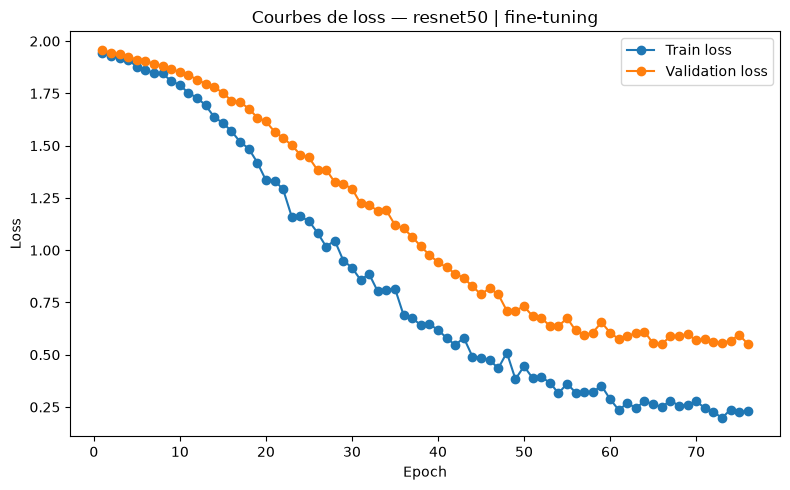

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(best_history["epoch"], best_history["train_loss"], marker="o", label="Train loss")
plt.plot(best_history["epoch"], best_history["val_loss"], marker="o", label="Validation loss")

plt.title(f"Courbes de loss — {best_model['model_label']}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

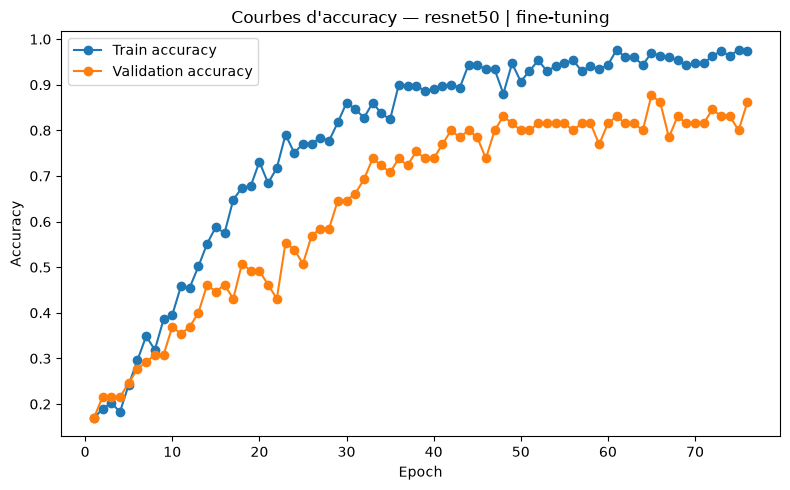

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(best_history["epoch"], best_history["train_acc"], marker="o", label="Train accuracy")
plt.plot(best_history["epoch"], best_history["val_acc"], marker="o", label="Validation accuracy")

plt.title(f"Courbes d'accuracy — {best_model['model_label']}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
best_history["loss_gap"] = best_history["val_loss"] - best_history["train_loss"]
best_history["accuracy_gap"] = best_history["train_acc"] - best_history["val_acc"]

best_history[
    ["epoch", "train_loss", "val_loss", "loss_gap", "train_acc", "val_acc", "accuracy_gap"]
]

,epoch,train_loss,val_loss,loss_gap,train_acc,val_acc,accuracy_gap
0,1,1.943825,1.958675,0.014850,0.169435,0.169231,0.000204
1,2,1.930621,1.943717,0.013096,0.189369,0.215385,-0.026016
2,3,1.921254,1.936028,0.014774,0.202658,0.215385,-0.012727
3,4,1.911017,1.925298,0.014281,0.182724,0.215385,-0.032660
4,5,1.877324,1.911873,0.034549,0.242525,0.246154,-0.003629
...,...,...,...,...,...,...,...
71,72,0.227941,0.558611,0.330670,0.963455,0.846154,0.117301
72,73,0.197090,0.557693,0.360603,0.973422,0.830769,0.142653
73,74,0.238066,0.567117,0.329051,0.963455,0.830769,0.132686
74,75,0.225391,0.594848,0.369458,0.976744,0.800000,0.176744


## Analyse des courbes d'entraînement

Les courbes d'entraînement permettent de vérifier si les modèles apprennent de manière stable et s'ils généralisent correctement sur le jeu de validation.

Un écart important entre les performances train et validation peut indiquer un surapprentissage, particulièrement probable dans ce projet en raison du faible nombre d'images disponibles. À l'inverse, des performances faibles sur les deux ensembles peuvent indiquer un sous-apprentissage ou une architecture insuffisamment adaptée.

Le modèle retenu doit donc être choisi non seulement à partir de ses métriques finales, mais aussi à partir de la stabilité de ses courbes d'apprentissage.

## Analyse des exemples mal classifiés

L'analyse des erreurs permet de dépasser les métriques globales et de comprendre concrètement les limites du modèle.

Pour chaque image mal classifiée, on observe :
- la vraie classe ;
- la classe prédite ;
- le score de confiance ;
- les éventuelles confusions récurrentes entre classes.

Cette analyse est importante dans un contexte médical, car certaines classes de plaies peuvent être visuellement proches ou partager des caractéristiques communes : couleur, texture, forme irrégulière, présence de sang, inflammation ou zone cutanée abîmée.

In [21]:
best_run_name = best_model["run_name"]

predictions_path = (
    PROJECT_ROOT
    / "reports"
    / "evaluation"
    / best_run_name
    / "val"
    / "predictions.csv"
)

predictions_df = pd.read_csv(predictions_path)

predictions_df.head()

,true_label,predicted_label,confidence,correct,top3
0,Bruises,Bruises,0.911855,True,"[{""class"": ""Bruises"", ""probability"": 0.9118551..."
1,Burns,Burns,0.873357,True,"[{""class"": ""Burns"", ""probability"": 0.873357355..."
2,Laceration,Laceration,0.840322,True,"[{""class"": ""Laceration"", ""probability"": 0.8403..."
3,Ingrown_nails,Ingrown_nails,0.930421,True,"[{""class"": ""Ingrown_nails"", ""probability"": 0.9..."
4,Stab_wound,Stab_wound,0.959507,True,"[{""class"": ""Stab_wound"", ""probability"": 0.9595..."


In [22]:
errors_df = predictions_df[predictions_df["correct"] == False].copy()

errors_df = errors_df.sort_values(
    by="confidence",
    ascending=False
).reset_index(drop=True)

print(f"Nombre total d'erreurs : {len(errors_df)}")
errors_df.head(10)

Nombre total d'erreurs : 9


,true_label,predicted_label,confidence,correct,top3
0,Abrasions,Cut,0.900244,False,"[{""class"": ""Cut"", ""probability"": 0.90024352073..."
1,Laceration,Abrasions,0.809565,False,"[{""class"": ""Abrasions"", ""probability"": 0.80956..."
2,Abrasions,Laceration,0.792780,False,"[{""class"": ""Laceration"", ""probability"": 0.7927..."
3,Cut,Ingrown_nails,0.537479,False,"[{""class"": ""Ingrown_nails"", ""probability"": 0.5..."
4,Laceration,Bruises,0.526749,False,"[{""class"": ""Bruises"", ""probability"": 0.5267494..."
5,Burns,Laceration,0.507970,False,"[{""class"": ""Laceration"", ""probability"": 0.5079..."
6,Abrasions,Burns,0.430118,False,"[{""class"": ""Burns"", ""probability"": 0.430117964..."
7,Abrasions,Cut,0.360143,False,"[{""class"": ""Cut"", ""probability"": 0.36014339327..."
8,Bruises,Burns,0.323277,False,"[{""class"": ""Burns"", ""probability"": 0.323276519..."


In [23]:
confusion_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs

,true_label,predicted_label,count
1,Abrasions,Cut,2
0,Abrasions,Burns,1
2,Abrasions,Laceration,1
3,Bruises,Burns,1
4,Burns,Laceration,1
5,Cut,Ingrown_nails,1
6,Laceration,Abrasions,1
7,Laceration,Bruises,1


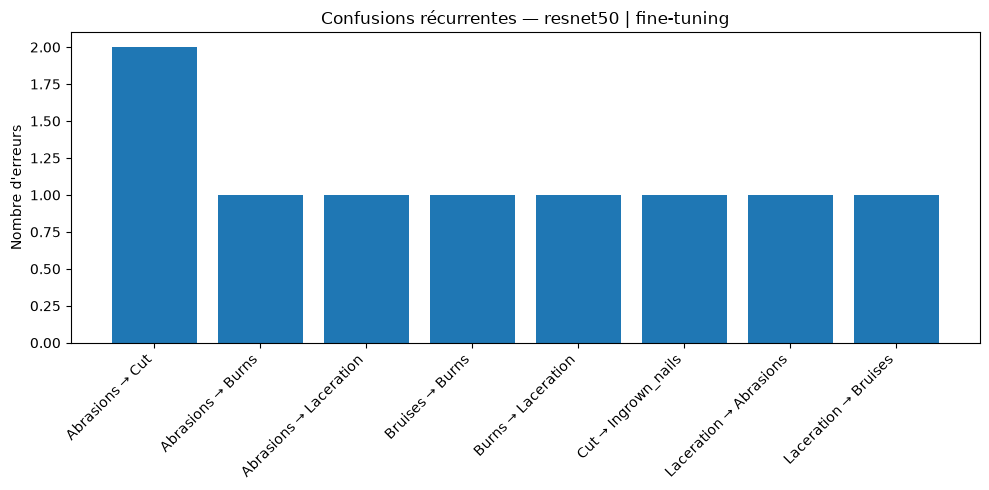

In [24]:
if len(confusion_pairs) > 0:
    labels = (
        confusion_pairs["true_label"]
        + " → "
        + confusion_pairs["predicted_label"]
    )

    plt.figure(figsize=(10, 5))
    plt.bar(labels, confusion_pairs["count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Nombre d'erreurs")
    plt.title(f"Confusions récurrentes — {best_model['model_label']}")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune erreur de classification pour ce modèle.")

../reports/evaluation/resnet50_pretrained-True_freeze-False_finetune-True_weighted-True_classweights-False_lr-1e-05_resnet50_finetune_final_100epochs_20260625_1618/val/misclassified_examples.png
Existe : True


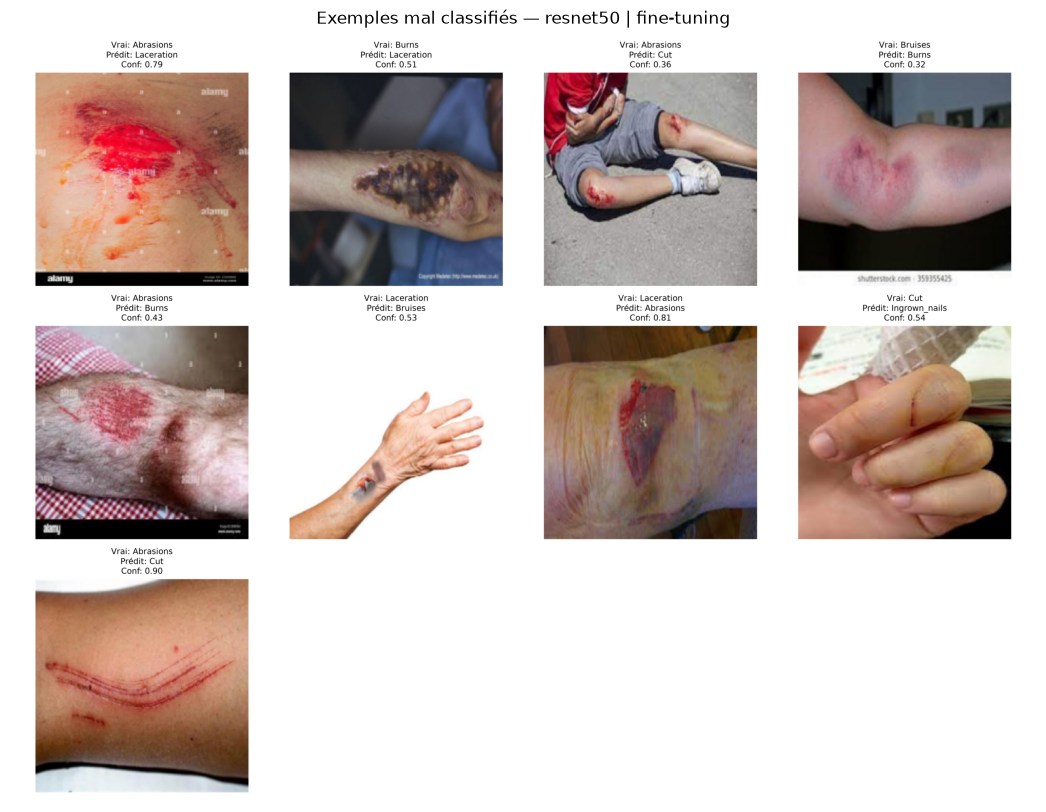

In [25]:
from PIL import Image

misclassified_path = (
    PROJECT_ROOT
    / "reports"
    / "evaluation"
    / best_run_name
    / "val"
    / "misclassified_examples.png"
)

print(misclassified_path)
print("Existe :", misclassified_path.exists())

if misclassified_path.exists():
    img = Image.open(misclassified_path)

    plt.figure(figsize=(14, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Exemples mal classifiés — {best_model['model_label']}")
    plt.show()
else:
    print("Aucune figure d'exemples mal classifiés trouvée.")

In [26]:
errors_by_true_class = (
    errors_df["true_label"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="num_errors")
)

errors_by_true_class

,class,num_errors
0,Abrasions,4
1,Laceration,2
2,Cut,1
3,Burns,1
4,Bruises,1


In [27]:
val_class_counts = (
    predictions_df["true_label"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="num_samples")
)

error_rate_by_class = val_class_counts.merge(
    errors_by_true_class,
    on="class",
    how="left"
).fillna(0)

error_rate_by_class["num_errors"] = error_rate_by_class["num_errors"].astype(int)
error_rate_by_class["error_rate"] = (
    error_rate_by_class["num_errors"] / error_rate_by_class["num_samples"]
).round(3)

error_rate_by_class = error_rate_by_class.sort_values(
    "error_rate",
    ascending=False
)

error_rate_by_class

,class,num_samples,num_errors,error_rate
1,Abrasions,13,4,0.308
3,Laceration,9,2,0.222
4,Cut,8,1,0.125
2,Burns,9,1,0.111
0,Bruises,18,1,0.056
5,Ingrown_nails,4,0,0.000
6,Stab_wound,4,0,0.000


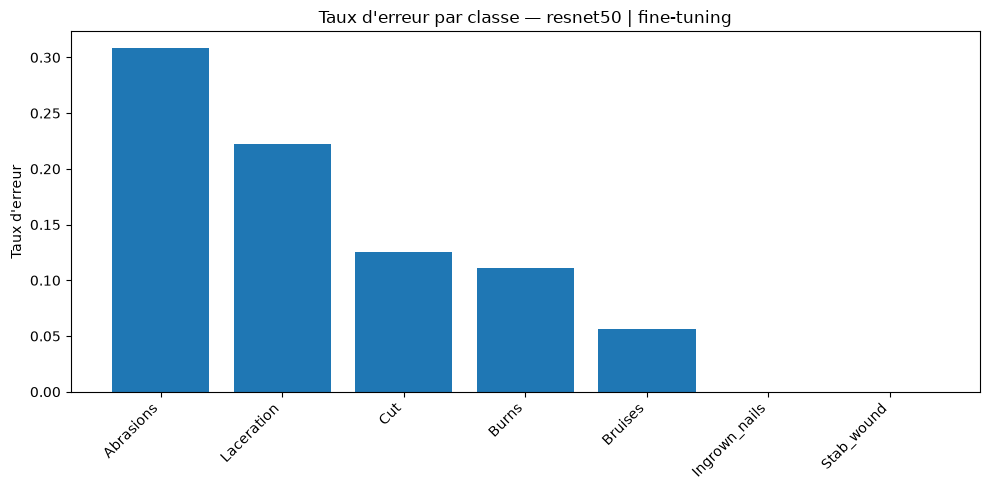

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(error_rate_by_class["class"], error_rate_by_class["error_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Taux d'erreur")
plt.title(f"Taux d'erreur par classe — {best_model['model_label']}")
plt.tight_layout()
plt.show()

In [29]:
high_confidence_errors = errors_df.head(10)

high_confidence_errors[
    ["true_label", "predicted_label", "confidence", "top3"]
]

,true_label,predicted_label,confidence,top3
0,Abrasions,Cut,0.900244,"[{""class"": ""Cut"", ""probability"": 0.90024352073..."
1,Laceration,Abrasions,0.809565,"[{""class"": ""Abrasions"", ""probability"": 0.80956..."
2,Abrasions,Laceration,0.792780,"[{""class"": ""Laceration"", ""probability"": 0.7927..."
3,Cut,Ingrown_nails,0.537479,"[{""class"": ""Ingrown_nails"", ""probability"": 0.5..."
4,Laceration,Bruises,0.526749,"[{""class"": ""Bruises"", ""probability"": 0.5267494..."
5,Burns,Laceration,0.507970,"[{""class"": ""Laceration"", ""probability"": 0.5079..."
6,Abrasions,Burns,0.430118,"[{""class"": ""Burns"", ""probability"": 0.430117964..."
7,Abrasions,Cut,0.360143,"[{""class"": ""Cut"", ""probability"": 0.36014339327..."
8,Bruises,Burns,0.323277,"[{""class"": ""Burns"", ""probability"": 0.323276519..."


## Lecture des erreurs de classification

L'analyse des exemples mal classifiés met en évidence les confusions les plus fréquentes du modèle retenu.  
Ces erreurs peuvent s'expliquer par plusieurs facteurs :

- certaines classes présentent des caractéristiques visuelles proches ;
- le dataset est de petite taille ;
- les classes minoritaires disposent de peu d'exemples d'apprentissage ;
- certaines images peuvent contenir des artefacts, des cadrages différents ou des conditions d'éclairage variables ;
- le modèle peut parfois se concentrer sur des éléments périphériques plutôt que sur la zone réellement discriminante de la plaie.

Les erreurs à forte confiance sont particulièrement importantes à surveiller. Elles montrent que le score de probabilité du CNN ne doit pas être interprété comme une certitude médicale. Cette limite justifie l'ajout d'un mécanisme de garde-fou, comme un autoencoder ou un modèle de détection hors-domaine, avant la classification finale.

Dans un contexte médical, le modèle doit donc être considéré comme un outil d'aide à l'analyse, et non comme un système autonome de diagnostic.

## Analyse des résultats de validation

Les nouveaux entraînements confirment que les modèles pré-entraînés restent nettement supérieurs au CNN custom entraîné from scratch. Le meilleur modèle sur le jeu de validation est désormais `ResNet50` avec fine-tuning partiel. Il obtient une accuracy de 0,862, un F1-score macro de 0,866 et seulement 9 erreurs sur 65 images de validation.

`MobileNetV3-Large` reste très compétitif : il atteint la même accuracy de 0,862 et le même nombre d’erreurs, mais son F1-score macro est légèrement inférieur, à 0,848. Cette différence est importante dans ce projet, car le macro-F1 donne le même poids à chaque classe et reflète mieux les performances sur un dataset déséquilibré. MobileNetV3-Large reste néanmoins un excellent candidat pour l’interface Streamlit grâce à son coût d’inférence plus faible.

Le `ResNet50` avec backbone gelé arrive ensuite. L’ancien run final `20260625_1618` a été conservé, car il est nettement meilleur que le nouveau run `20260625_1700` : macro-F1 de 0,755 contre 0,653 et accuracy de 0,754 contre 0,662. Cette variation montre que l’entraînement reste sensible à l’aléatoire du sampler pondéré, des augmentations et de l’initialisation de la tête de classification.

Pour `VGG16`, macro-F1 de 0,558 contre 0,542 et accuracy de 0,523 contre 0,508. Il reste toutefois moins performant que ResNet50 et MobileNetV3-Large, ce qui confirme que VGG16 sert surtout de baseline classique.

`EfficientNet-B0` et le `custom_cnn` obtiennent les résultats les plus faibles dans cette comparaison. Le CNN custom, entraîné sans poids ImageNet, confirme l’intérêt du transfer learning sur un dataset médical petit et déséquilibré.

À ce stade, `ResNet50` en fine-tuning partiel est retenu comme meilleur modèle de validation. `MobileNetV3-Large` reste une alternative intéressante si la priorité est la rapidité d’inférence. Le jeu de test doit rester réservé à l’évaluation finale du modèle choisi.



In [30]:
OUTPUT_PATH = PROJECT_ROOT / "reports" / "evaluation" / "model_comparison_val_enriched.csv"

df_sorted.to_csv(OUTPUT_PATH, index=False)

print(f"Table enrichie sauvegardée dans : {OUTPUT_PATH}")

Table enrichie sauvegardée dans : ../reports/evaluation/model_comparison_val_enriched.csv
